In [11]:
# Install and import necessary libraries
!pip install monai tqdm torch torchvision

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
from monai.transforms import Compose, ScaleIntensity, ToTensor
from generative.inferers import VQVAETransformerInferer
from generative.networks.nets import VQVAE, DecoderOnlyTransformer
from generative.utils.ordering import Ordering
from generative.utils.enums import OrderingType

print(torch.__version__)


2.3.1+cpu


In [12]:
from sklearn.datasets import load_digits

# Load the digits dataset
digits = load_digits()
X, y = digits.data / 16.0, digits.target  # Normalize the data
X = X.reshape(-1, 1, 8, 8)  # Reshape to (n_samples, 1, 8, 8)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the VQ-VAE model using MONAI
vqvae_model = VQVAE(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    num_res_layers=2,
    downsample_parameters=((2, 4, 1, 1), (2, 4, 1, 1)),
    upsample_parameters=((2, 4, 1, 1, 0), (2, 4, 1, 1, 0)),
    num_channels=(256, 256),
    num_res_channels=(256, 256),
    num_embeddings=256,
    embedding_dim=32,
)
vqvae_model = vqvae_model.to(device)

optimizer = torch.optim.Adam(params=vqvae_model.parameters(), lr=1e-4)
l1_loss = nn.L1Loss()

num_epochs = 100
vqvae_model.train()

for epoch in range(num_epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        reconstruction, quantization_loss = vqvae_model(images=data)
        recons_loss = l1_loss(reconstruction.float(), data.float())
        loss = recons_loss + quantization_loss
        loss.backward()
        optimizer.step()
        train_loss += recons_loss.item()

    print(f'Epoch {epoch + 1}, Reconstruction Loss: {train_loss / len(train_loader.dataset)}')


Epoch 1, Reconstruction Loss: 0.002675773351658693
Epoch 2, Reconstruction Loss: 0.001924090507383884
Epoch 3, Reconstruction Loss: 0.0016599984719011629
Epoch 4, Reconstruction Loss: 0.001570815312505681
Epoch 5, Reconstruction Loss: 0.00155642082190132
Epoch 6, Reconstruction Loss: 0.0015527051131428325
Epoch 7, Reconstruction Loss: 0.0015479675082589656
Epoch 8, Reconstruction Loss: 0.0015467445449689734
Epoch 9, Reconstruction Loss: 0.001522011095729236
Epoch 10, Reconstruction Loss: 0.001447342403580434
Epoch 11, Reconstruction Loss: 0.0013472809298800028
Epoch 12, Reconstruction Loss: 0.0013145049599698623
Epoch 13, Reconstruction Loss: 0.0012728208332486509
Epoch 14, Reconstruction Loss: 0.0011952661584463896
Epoch 15, Reconstruction Loss: 0.0011309847785270122
Epoch 16, Reconstruction Loss: 0.0010796551726805143
Epoch 17, Reconstruction Loss: 0.0010295832476519677
Epoch 18, Reconstruction Loss: 0.0009871830615469708
Epoch 19, Reconstruction Loss: 0.0009650123268676949
Epoch 20,

In [15]:
# Define the Transformer model
transformer_model = DecoderOnlyTransformer(
    num_tokens=256 + 1,  # 256 from num_embeddings input of VQVAE + 1 for BOS token
    max_seq_len=64,  # assuming 8x8 encoded space flattened
    attn_layers_dim=96,
    attn_layers_depth=12,
    attn_layers_heads=8,
)
transformer_model = transformer_model.to(device)

inferer = VQVAETransformerInferer()
optimizer = torch.optim.Adam(params=transformer_model.parameters(), lr=5e-4)
ce_loss = nn.CrossEntropyLoss()

# Define ordering for sequence conversion
spatial_shape = vqvae_model.encode_stage_2_inputs(torch.rand(1, 1, 8, 8).to(device)).shape[2:]
ordering = Ordering(ordering_type=OrderingType.RASTER_SCAN.value, spatial_dims=2, dimensions=(1,) + spatial_shape)
bos_token = 256

# Transformer training loop
n_epochs = 50
for epoch in range(n_epochs):
    transformer_model.train()
    train_loss = 0
    for step, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits, target, _ = inferer(data, vqvae_model, transformer_model, ordering, return_latent=True)
        logits = logits.transpose(1, 2)
        loss = ce_loss(logits, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f'Epoch {epoch + 1}, CE Loss: {train_loss / len(train_loader.dataset)}')


Epoch 1, CE Loss: 0.04672113556619643
Epoch 2, CE Loss: 0.041678181769703525
Epoch 3, CE Loss: 0.03886104509410712
Epoch 4, CE Loss: 0.03741241745759649
Epoch 5, CE Loss: 0.03626315694927091
Epoch 6, CE Loss: 0.035318736658381686
Epoch 7, CE Loss: 0.03409913138706151
Epoch 8, CE Loss: 0.03331333394671117
Epoch 9, CE Loss: 0.032375382315224875
Epoch 10, CE Loss: 0.03132719253614369
Epoch 11, CE Loss: 0.03033329134777178
Epoch 12, CE Loss: 0.029252759930817055
Epoch 13, CE Loss: 0.02833773779553843
Epoch 14, CE Loss: 0.027397984502708736
Epoch 15, CE Loss: 0.02638798516578117
Epoch 16, CE Loss: 0.025527053353847858
Epoch 17, CE Loss: 0.024543658012968844
Epoch 18, CE Loss: 0.02376077037431668
Epoch 19, CE Loss: 0.02293783803739395
Epoch 20, CE Loss: 0.02206479333387785
Epoch 21, CE Loss: 0.02148566000479829
Epoch 22, CE Loss: 0.020911496135204637
Epoch 23, CE Loss: 0.02006578246337636
Epoch 24, CE Loss: 0.01956700996632533
Epoch 25, CE Loss: 0.019189453324096935
Epoch 26, CE Loss: 0.0187

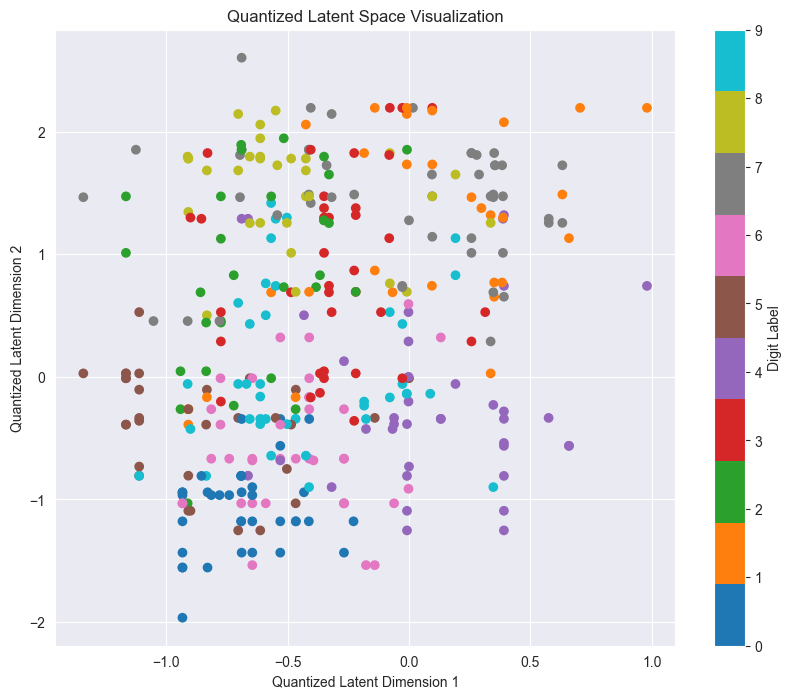

In [19]:
vqvae_model.eval()
z_means = []
labels = []
with torch.no_grad():
    for data, label in test_loader:
        data = data.to(device)
        quantized = vqvae_model.encode_stage_2_inputs(data)  # Ensure to get the correct encoding stage
        z_means.append(quantized.view(quantized.size(0), -1))  # Flatten the quantized representation
        labels.append(label)

z_means = torch.cat(z_means).cpu().numpy()
labels = torch.cat(labels).numpy()

plt.figure(figsize=(10, 8))
plt.scatter(z_means[:, 0], z_means[:, 1], c=labels, cmap='tab10')
plt.colorbar(label='Digit Label')
plt.xlabel('Quantized Latent Dimension 1')
plt.ylabel('Quantized Latent Dimension 2')
plt.title('Quantized Latent Space Visualization')
plt.show()


In [ ]:
import random

def generate_saliency_map(vqvae, data_point):
    vqvae.eval()
    data_point.requires_grad = True
    _, z_mean, _ = vqvae(data_point)
    loss = z_mean.sum()  # Sum the latent variables to create a scalar
    loss.backward()
    saliency = data_point.grad.abs().detach()
    return saliency

# Select a random image from the test set
random_index = random.randint(0, len(test_dataset) - 1)
data_point, label = test_dataset[random_index]
data_point, label = data_point.unsqueeze(0).to(device), label

# Generate saliency map
saliency_map = generate_saliency_map(vqvae_model, data_point)

# Print the index of the chosen image
print(f'Randomly chosen image index: {random_index}')

# Plot the saliency map
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f'Original Image (Label: {label.item()})')
plt.imshow(data_point.cpu().detach().squeeze(), cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Saliency Map')
plt.imshow(saliency_map.cpu().detach().squeeze(), cmap='hot')
plt.colorbar()
plt.show()
